# argentina.data — EPH y Censo

Recorrido **usando el paquete** para:

1. Verificar que `import argentina` sigue siendo liviano.
2. Descargar **microdatos de la EPH** (INDEC) y hacer análisis básicos.
3. Probar la arquitectura de Censo 2022 (parquets remotos + DuckDB).

Requiere el extra: `pip install "argentina[data]"`.

## 1. Setup

In [1]:
import argentina as arg
import pandas as pd
import matplotlib.pyplot as plt

print(f'argentina v{arg.__version__}')

argentina v0.0.23


## 2. El import sigue siendo liviano

Aunque `arg.data.eph` y `arg.data.censo` usan pandas/requests/duckdb, esos se importan recién cuando se llama la función — no al `import argentina`.

In [2]:
import subprocess, sys
code = (
    'import sys, argentina; '
    'mods = [m for m in ["pandas", "requests", "duckdb", "pyarrow"] if m in sys.modules]; '
    'print("deps cargadas al import:", mods or "ninguna")'
)
print(subprocess.check_output([sys.executable, '-c', code]).decode().strip())

deps cargadas al import: ninguna


## 3. EPH trimestral en vivo (INDEC)

Descarga el ZIP oficial del INDEC, lo cachea bajo `~/.cache/argentina/eph/` y lee el txt como DataFrame. La primera llamada baja ~3-5 MB (~5-30 s según red). Las siguientes son cache hits.

In [3]:
ind = arg.data.eph(anio=2024, periodo='trimestral', numero=1, tipo='individual')
hog = arg.data.eph(anio=2024, periodo='trimestral', numero=1, tipo='hogar')

print(f'Individual (personas): {len(ind):,} filas, {len(ind.columns)} columnas'.replace(',', '.'))
print(f'Hogar:                 {len(hog):,} filas, {len(hog.columns)} columnas'.replace(',', '.'))

Individual (personas): 46.050 filas. 235 columnas
Hogar:                 16.104 filas. 98 columnas


In [4]:
# Algunas variables clave de la EPH individual:
#   CH04: sexo (1=varón, 2=mujer)
#   CH06: edad
#   REGION: 1=GBA, 40=NOA, 41=NEA, 42=Cuyo, 43=Pampeana, 44=Patagonia
#   PONDERA: ponderador muestral
ind[['CODUSU', 'ANO4', 'TRIMESTRE', 'REGION', 'CH04', 'CH06', 'PONDERA']].head()

,CODUSU,ANO4,TRIMESTRE,REGION,CH04,CH06,PONDERA
0,TQRMNOSTSHJOLOCDEHLEH00795168,2024,1,40,2,86,140
1,TQRMNOSQYHJMLPCDEIKAH00793199,2024,1,43,1,68,648
2,TQRMNOSQYHJMLPCDEIKAH00793199,2024,1,43,1,20,648
3,TQRMNORWPHJOLLCDEGPDJ00795996,2024,1,40,2,75,281
4,TQRMNOTQRHJMLOCDEHJGH00794657,2024,1,40,2,41,252


## 4. Análisis: pirámide de edades del Q1 2024

Usamos el ponderador `PONDERA` para escalar la muestra a la población.

In [5]:
# Filtrar edades válidas (-1 = sin respuesta)
df = ind[(ind['CH06'] >= 0) & (ind['CH06'] <= 100)].copy()

bins = list(range(0, 101, 5))
df['grupo_edad'] = pd.cut(df['CH06'], bins=bins, right=False)

piramide = (
    df.groupby(['grupo_edad', 'CH04'], observed=True)['PONDERA']
      .sum()
      .unstack(fill_value=0)
      .rename(columns={1: 'varones', 2: 'mujeres'})
)
piramide.head(10)

CH04,varones,mujeres
grupo_edad,,
"[0, 5)",709737,626347
"[5, 10)",1294369,1213444
"[10, 15)",1327842,1284236
"[15, 20)",1167273,1115109
"[20, 25)",1217832,1117818
"[25, 30)",987424,1047303
"[30, 35)",1029879,1076913
"[35, 40)",951095,1042234
"[40, 45)",962977,1034443


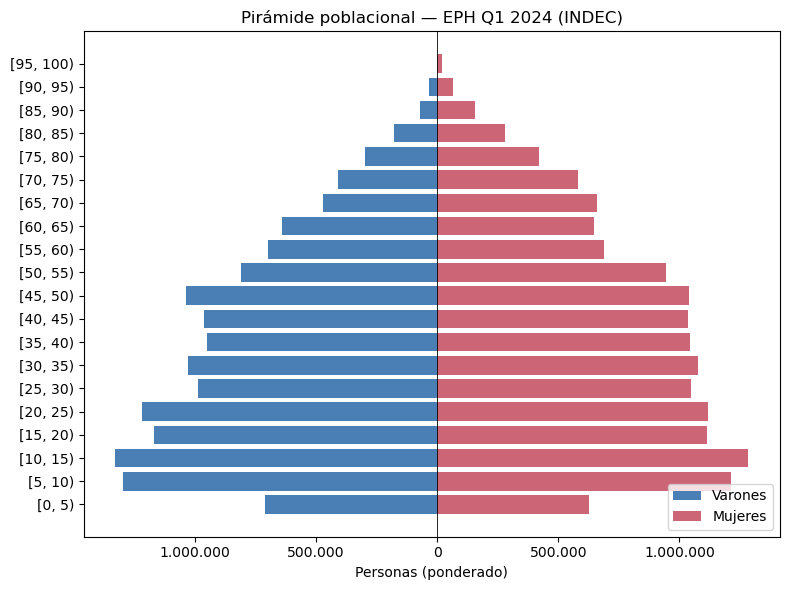

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
y = range(len(piramide))
ax.barh(y, -piramide['varones'], color='#4a7fb5', label='Varones')
ax.barh(y,  piramide['mujeres'], color='#cc6677', label='Mujeres')
ax.set_yticks(y)
ax.set_yticklabels([str(i) for i in piramide.index])
ax.set_xlabel('Personas (ponderado)')
ax.set_title('Pirámide poblacional — EPH Q1 2024 (INDEC)')
ax.legend(loc='lower right')
ax.axvline(0, color='black', linewidth=0.6)
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(abs(x)):,}'.replace(',', '.')))
plt.tight_layout()
plt.show()

## 5. Distribución por región (con ponderador)

In [7]:
REGIONES = {
    1: 'GBA',
    40: 'NOA',
    41: 'NEA',
    42: 'Cuyo',
    43: 'Pampeana',
    44: 'Patagonia',
}

ind['region_nombre'] = ind['REGION'].map(REGIONES)
por_region = ind.groupby('region_nombre')['PONDERA'].sum().sort_values(ascending=False)
por_region

region_nombre
GBA          15953654
Pampeana      6375448
NOA           2825347
Cuyo          1855340
NEA           1464441
Patagonia     1118984
Name: PONDERA, dtype: int64

## 6. Ingreso medio de la población ocupada (P21)

`P21` es el ingreso de la ocupación principal. `ESTADO=1` filtra ocupados.

In [8]:
ocupados = ind[(ind['ESTADO'] == 1) & (ind['P21'] > 0)].copy()

# Ingreso medio simple
media = (ocupados['P21'] * ocupados['PONDERA']).sum() / ocupados['PONDERA'].sum()
mediana = ocupados['P21'].median()
print(f'Ingreso medio (ponderado):    ${media:>10,.0f}'.replace(',', '.'))
print(f'Ingreso mediana (sin ponderar): ${mediana:>10,.0f}'.replace(',', '.'))
print(f'Ocupados en la muestra:        {len(ocupados):,}'.replace(',', '.'))

Ingreso medio (ponderado):    $   343.306
Ingreso mediana (sin ponderar): $   250.000
Ocupados en la muestra:        16.513


## 7. Censo 2022 — arquitectura DuckDB + Parquet remoto

`arg.data.censo` está implementado contra DuckDB: hace `SELECT ... FROM read_parquet('https://...')` y trae solo lo pedido (no descarga el dataset entero).

**Estado actual:** el INDEC no publica todavía microdatos del Censo 2022 como parquets accesibles vía HTTPS, así que las URLs en `CENSO_PARQUETS_2022` están vacías. Si tenés un mirror propio (o cuando aparezca uno oficial), lo configurás así:

In [9]:
# Sin configurar → error claro pidiendo URL
try:
    arg.data.censo(anio=2022, tabla='personas')
except ValueError as e:
    print('ValueError:', e)

ValueError: No hay URL configurada para tabla 'personas'. Configurá CENSO_PARQUETS_2022 o pasá 'url=' a la función. El INDEC aún no publica microdatos parquet del Censo 2022.


In [10]:
# Ejemplo de cómo se usaría con una URL configurada:
#
#   import argentina.data.censo as c
#   c.CENSO_PARQUETS_2022['personas'] = 'https://mi-mirror/personas.parquet'
#
#   df = arg.data.censo(
#       anio=2022,
#       tabla='personas',
#       provincia='Córdoba',
#       limite=10000,
#   )
#
# Internamente arma:
#   SELECT * FROM read_parquet('https://mi-mirror/personas.parquet')
#   WHERE provincia_codigo = '14'
#   LIMIT 10000
#
# DuckDB usa HTTP Range para traer solo lo necesario.
print('Censo: arquitectura lista, esperando URLs oficiales.')

Censo: arquitectura lista, esperando URLs oficiales.


## 8. Mientras tanto, datos agregados sin red

Para población provincial / ciudades del Censo 2022 (datos agregados, no microdatos), ya existe sin descargar nada:

In [11]:
# Provincias por población — embebido en el paquete (Censo 2022)
top5 = sorted(arg.provincias, key=lambda p: p.poblacion_2022 or 0, reverse=True)[:5]
for p in top5:
    print(f'  {p.nombre:35s}  {p.poblacion_2022:>11,}'.replace(',', '.'))

  Buenos Aires                          17.569.053
  Córdoba                                3.840.905
  Santa Fe                               3.556.522
  Ciudad Autónoma de Buenos Aires        3.121.707
  Mendoza                                2.014.533


## Notas

- **EPH:** descarga implementada contra el FTP oficial del INDEC. Cache local en `~/.cache/argentina/eph/T<N>_<año>/`. Soporta `tipo='individual'` (personas) y `tipo='hogar'`. Solo trimestral; la semestral (pre-2003) queda como `NotImplementedError`.
- **Censo 2022:** arquitectura DuckDB lista (parquets remotos consultados con `SELECT ... FROM read_parquet(...)`). Configurar URLs en `argentina.data.censo.CENSO_PARQUETS_2022` o pasar `url=` al llamar. Filtros por provincia/departamento usan los códigos INDEC del paquete (`arg.provincias.lookup`, `arg.departamentos.lookup`).
- Para datasets agregados del Censo 2022 ya hay APIs livianas: `arg.provincias.<X>.poblacion_2022`, `arg.ciudades.top(n)`.